<a href="https://colab.research.google.com/github/f223455-bit/Computer_Vision_Basics/blob/main/Linta_22F_3455_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time

In [2]:
!git clone https://github.com/f223455-bit/Computer_Vision_Basics.git

Cloning into 'Computer_Vision_Basics'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 34 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 1.48 MiB | 2.05 MiB/s, done.
Resolving deltas: 100% (11/11), done.


# Load Images

In [3]:
dog = cv2.imread("Computer_Vision_Basics/Test_Images/Dog.jfif",0)
flower = cv2.imread("Computer_Vision_Basics/Test_Images/Flowers.jfif",0)
pirate = cv2.imread("Computer_Vision_Basics/Test_Images/Pirates.jfif",0)

images = [dog, flower, pirate]
names = ["Dog","Flower","Pirate"]

for img,name in zip(images,names):
    if img is None:
        print(f"{name} not loaded. Check path.")
    else:
        print(f"{name} loaded successfully")

Dog loaded successfully
Flower loaded successfully
Pirate loaded successfully


#QUESTION 1
#Histogram Equalization

In [4]:
def histogram_equalization(img):

    # Step 1: Histogram calculation
    hist = np.zeros(256)

    for pixel in img.flatten():
        hist[pixel] += 1

    # Step 2: Probability distribution
    pdf = hist / img.size

    # Step 3: Cumulative distribution function
    cdf = np.cumsum(pdf)

    # Step 4: Transformation mapping
    transform = np.round(cdf * 255).astype(np.uint8)

    # Step 5: Apply transformation
    equalized = transform[img]

    return equalized, hist, transform

#Display Results

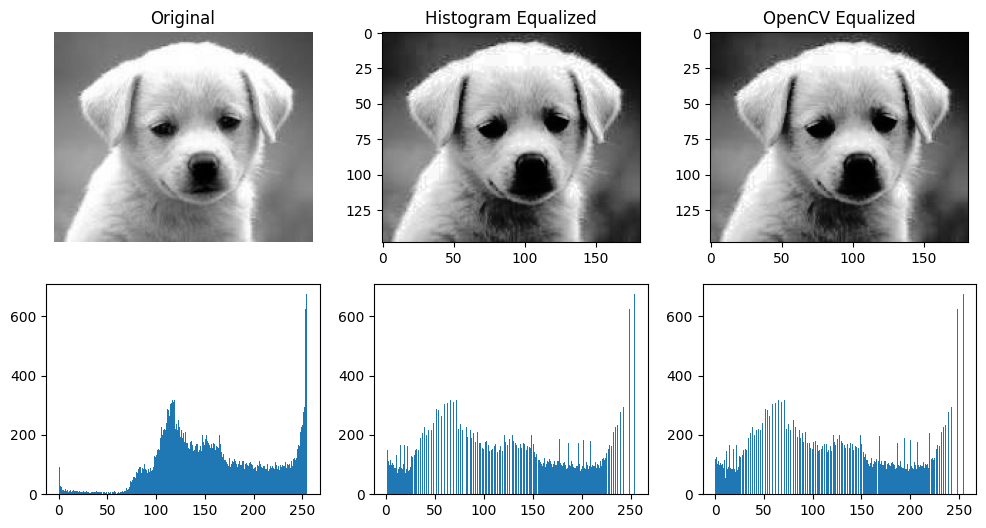

Transformation Mapping Array:
[  1   1   1   2   2   2   2   2   2   2   3   3   3   3   3   3   3   3
   3   4   4   4   4   4   4   4   4   4   4   4   4   4   4   4   5   5
   5   5   5   5   5   5   5   5   5   5   5   6   6   6   6   6   6   6
   6   6   6   6   6   6   6   6   6   6   6   7   7   7   7   7   7   7
   8   8   8   9   9  10  10  11  11  12  13  14  15  15  16  17  18  19
  19  20  21  22  22  23  24  25  26  27  29  30  31  33  35  37  39  41
  43  45  47  49  52  54  57  60  63  66  69  72  74  76  78  80  83  84
  87  88  90  92  94  96  97  99 100 102 103 105 106 108 109 111 112 114
 115 117 118 120 122 123 125 127 129 130 132 133 135 137 138 140 141 143
 144 146 147 149 151 152 153 154 156 157 158 159 160 161 162 163 164 165
 166 167 168 169 170 171 172 173 174 175 176 177 177 178 179 180 181 182
 183 184 185 186 187 187 188 189 190 191 192 193 194 195 196 197 197 198
 199 200 201 202 202 203 204 205 206 207 208 209 209 210 211 212 213 214
 215 216 217 218 219 

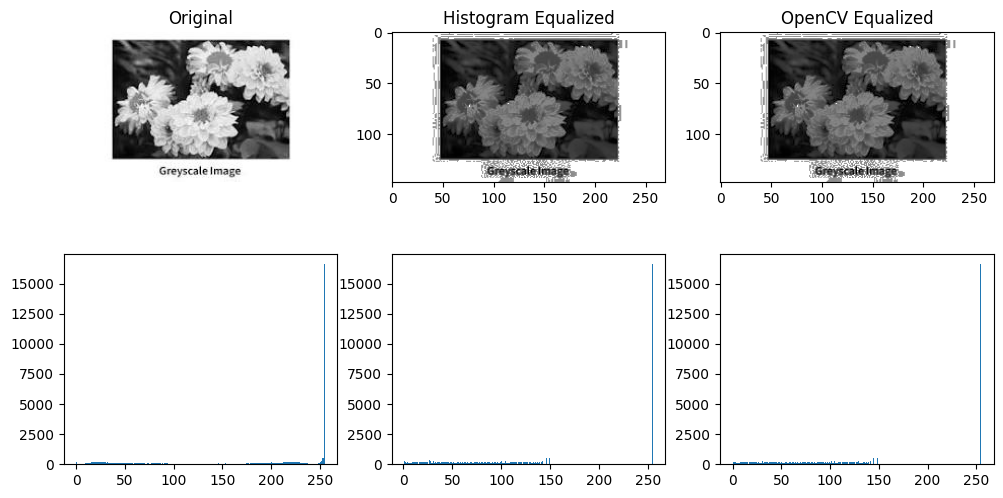

Transformation Mapping Array:
[  1   1   2   2   2   2   3   3   4   4   4   5   6   7   8   9  10  11
  12  13  14  16  17  18  19  20  21  22  23  24  26  26  28  28  29  30
  31  31  32  33  33  34  35  35  36  36  37  37  38  39  39  40  40  41
  41  42  42  43  43  44  44  45  45  46  46  47  47  48  48  49  49  50
  50  51  51  51  52  52  53  53  54  54  55  55  55  56  56  57  57  58
  58  58  59  59  60  60  60  61  61  61  62  62  62  63  63  63  63  64
  64  64  64  65  65  65  65  66  66  66  66  67  67  67  67  68  68  68
  69  69  69  69  70  70  70  70  71  71  71  72  72  72  73  73  73  74
  74  74  75  75  75  76  76  76  77  77  78  78  78  78  79  79  80  80
  80  81  81  81  82  82  83  83  83  84  84  84  85  85  86  86  86  87
  87  88  88  89  89  90  90  91  91  92  93  93  94  94  95  96  96  97
  97  98  99 100 101 101 102 103 104 105 105 106 107 108 109 110 111 112
 113 114 115 116 118 119 120 121 123 124 125 126 127 128 129 130 131 132
 133 133 134 135 135 

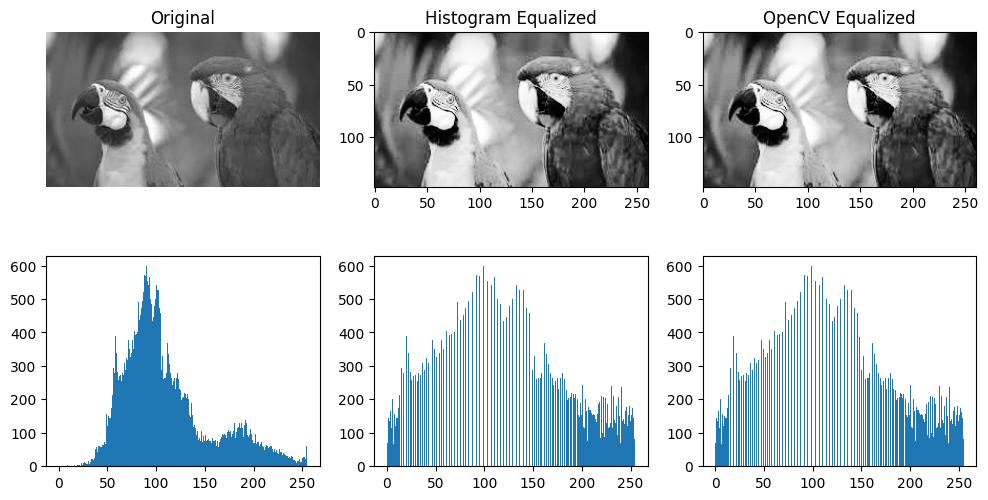

Transformation Mapping Array:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   1   1   1   1   1   1   1   1   1
   1   2   2   2   3   3   3   4   4   5   5   5   6   7   8   9  10  11
  12  13  15  17  20  22  24  25  27  29  31  32  34  36  38  40  42  44
  47  49  51  54  56  58  61  64  66  69  72  75  78  81  84  88  92  95
  99 103 107 110 114 117 120 123 126 129 133 136 140 143 146 148 150 152
 154 156 158 159 162 164 166 168 170 171 173 175 176 178 180 182 183 185
 186 187 189 190 192 193 194 196 197 198 199 200 201 201 202 203 204 204
 205 205 206 207 207 208 208 209 209 210 210 211 211 212 212 213 213 214
 214 215 215 216 216 217 217 218 219 219 220 221 221 222 223 223 224 225
 225 226 227 227 228 229 230 231 231 232 233 233 234 235 236 236 237 238
 238 239 239 240 241 241 241 242 242 243 243 244 244 245 245 245 246 246
 246 247 247 248 248 248 249 249 249 249 250 250 250 251 251 251 251 252
 252 252 252 252 252 

In [5]:
for img,name in zip(images,names):

    eq_img, hist, transform = histogram_equalization(img)

    opencv_eq = cv2.equalizeHist(img)

    plt.figure(figsize=(12,6))

    # Original image
    plt.subplot(2,3,1)
    plt.imshow(img,cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Scratch equalization
    plt.subplot(2,3,2)
    plt.imshow(eq_img,cmap='gray')
    plt.title("Histogram Equalized")

    # OpenCV comparison
    plt.subplot(2,3,3)
    plt.imshow(opencv_eq,cmap='gray')
    plt.title("OpenCV Equalized")

    # Histograms
    plt.subplot(2,3,4)
    plt.hist(img.flatten(),256)

    plt.subplot(2,3,5)
    plt.hist(eq_img.flatten(),256)

    plt.subplot(2,3,6)
    plt.hist(opencv_eq.flatten(),256)

    plt.show()

    print("Transformation Mapping Array:")
    print(transform)

# Part (b) Contrast Stretching
Formula:

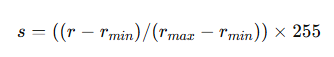

In [6]:
def contrast_stretch(img):

    r_min = np.min(img)
    r_max = np.max(img)

    stretched = (img - r_min) / (r_max - r_min) * 255

    return stretched.astype(np.uint8)

#Apply & Compare

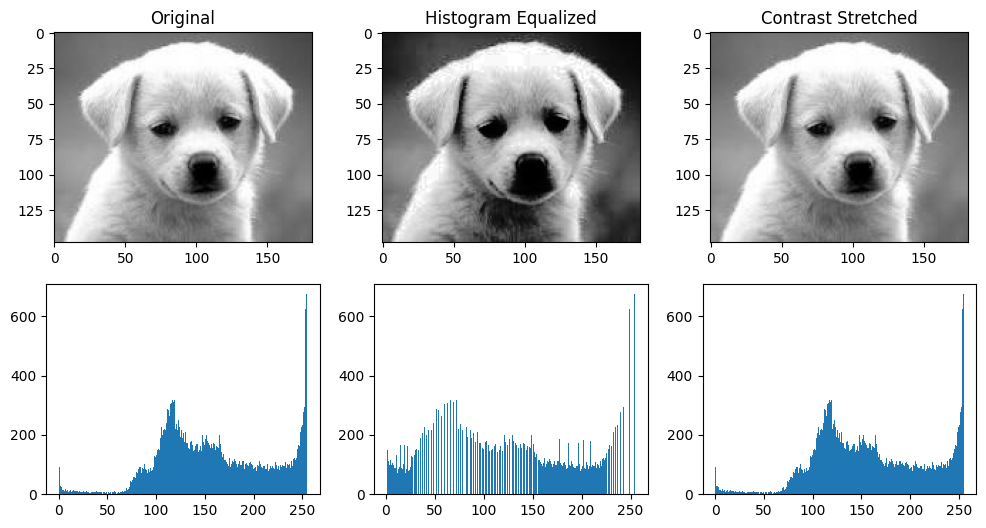

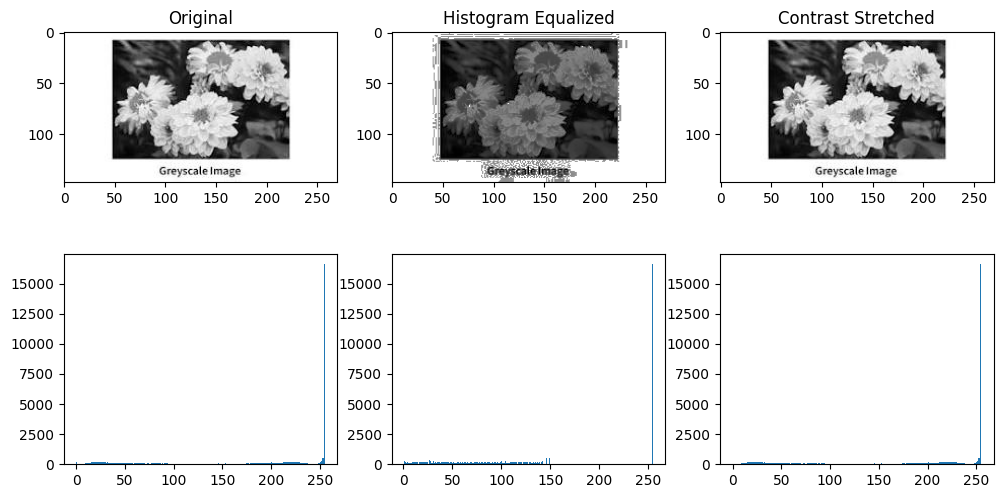

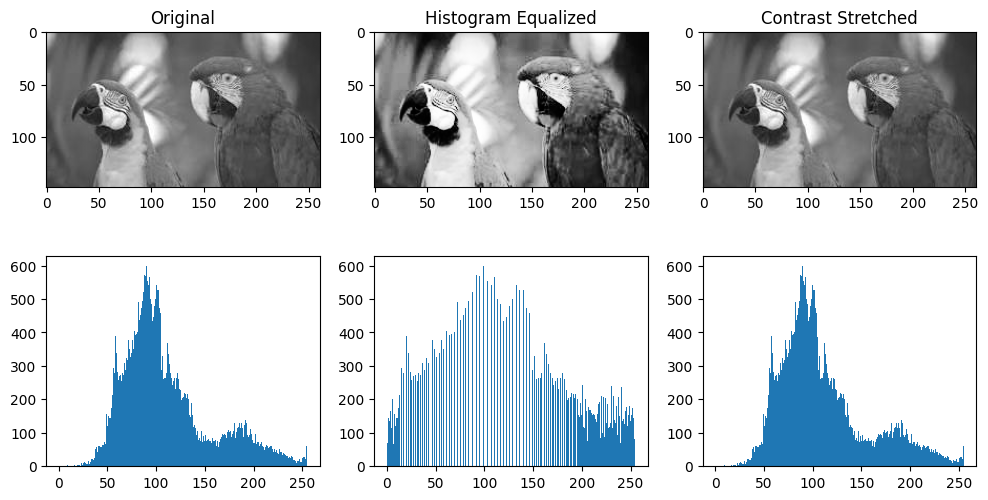

In [7]:
for img,name in zip(images,names):

    eq_img,_,_ = histogram_equalization(img)
    stretch_img = contrast_stretch(img)

    plt.figure(figsize=(12,6))

    plt.subplot(2,3,1)
    plt.imshow(img,cmap='gray')
    plt.title("Original")

    plt.subplot(2,3,2)
    plt.imshow(eq_img,cmap='gray')
    plt.title("Histogram Equalized")

    plt.subplot(2,3,3)
    plt.imshow(stretch_img,cmap='gray')
    plt.title("Contrast Stretched")

    plt.subplot(2,3,4)
    plt.hist(img.flatten(),256)

    plt.subplot(2,3,5)
    plt.hist(eq_img.flatten(),256)

    plt.subplot(2,3,6)
    plt.hist(stretch_img.flatten(),256)

    plt.show()

# Part (c) Gamma (Power-Law) Transformation

In [8]:
def gamma_correction(img,gamma):

    normalized = img / 255.0

    corrected = np.power(normalized, gamma)

    return np.uint8(corrected * 255)

Apply Different Gamma Values

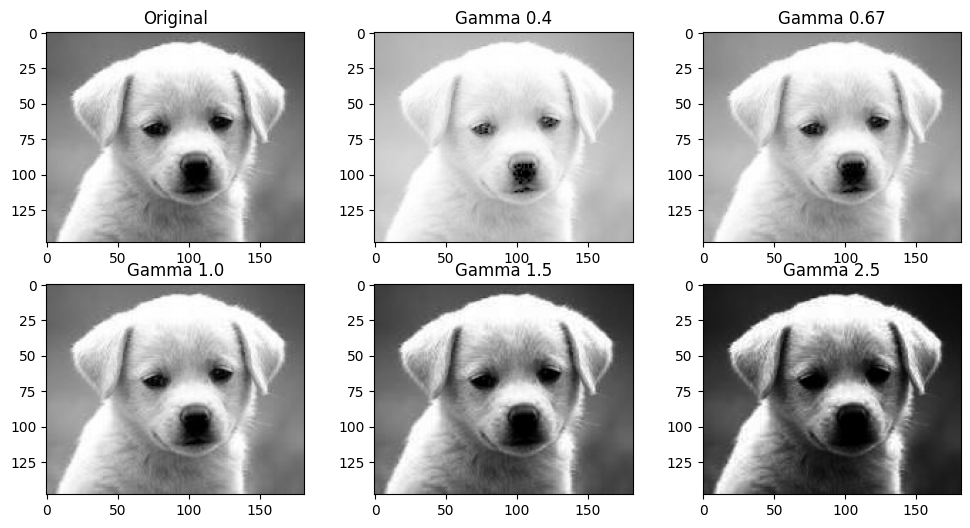

In [9]:
gamma_values = [0.4,0.67,1.0,1.5,2.5]

img = dog

plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img,cmap='gray')
plt.title("Original")

for i,gamma in enumerate(gamma_values):

    gamma_img = gamma_correction(img,gamma)

    plt.subplot(2,3,i+2)
    plt.imshow(gamma_img,cmap='gray')
    plt.title(f"Gamma {gamma}")

plt.show()

QUESTION 2 — Image Filtering and Convolution
#Part (a) 2D Convolution From Scratch
#Convolution Function

In [10]:
def convolution2D(image, kernel, padding='zero'):

    k = kernel.shape[0]
    pad = k//2

    if padding == 'zero':
        padded = np.pad(image,pad,mode='constant')

    elif padding == 'edge':
        padded = np.pad(image,pad,mode='edge')

    elif padding == 'none':
        padded = image

    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            region = padded[i:i+k, j:j+k]

            if region.shape == kernel.shape:
                output[i,j] = np.sum(region * kernel)

    return output

#Kernels

In [11]:
box_filter = (1/9) * np.ones((3,3))

identity_kernel = np.array([
[0,0,0],
[0,1,0],
[0,0,0]])

edge_kernel = np.array([
[-1,-1,-1],
[-1,8,-1],
[-1,-1,-1]])

#Test + Compare With OpenCV

Execution Time: 0.21673035621643066


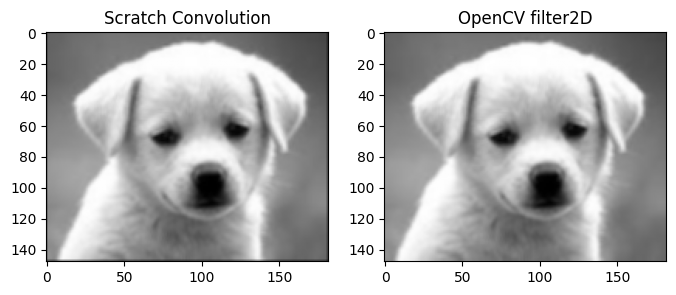

Execution Time: 0.2056713104248047


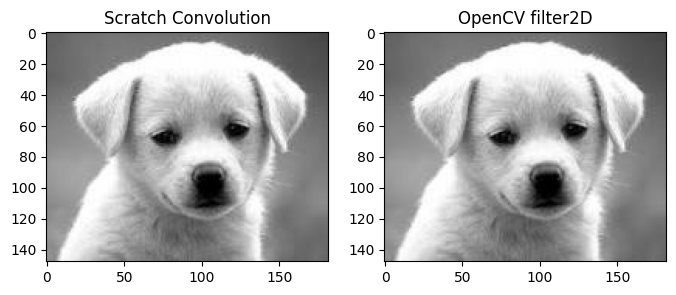

Execution Time: 0.21615839004516602


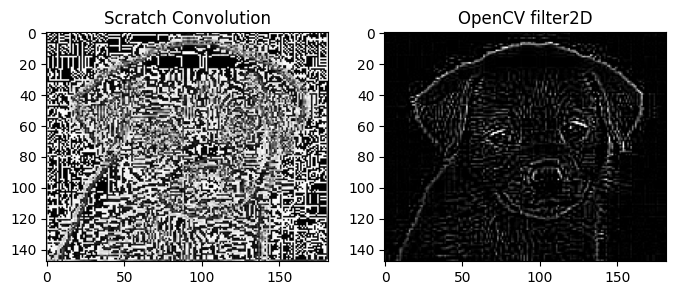

In [12]:
kernels = [box_filter,identity_kernel,edge_kernel]

for kernel in kernels:

    start = time.time()

    result = convolution2D(dog,kernel)

    end = time.time()

    print("Execution Time:", end-start)

    cv_result = cv2.filter2D(dog,-1,kernel)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(result,cmap='gray')
    plt.title("Scratch Convolution")

    plt.subplot(1,2,2)
    plt.imshow(cv_result,cmap='gray')
    plt.title("OpenCV filter2D")

    plt.show()

#Part (b) Gaussian Filter

#Gaussian Kernel

In [13]:
def gaussian_kernel(size, sigma):

    ax = np.arange(-(size//2), size//2 + 1)

    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))

    kernel = kernel / np.sum(kernel)

    return kernel

#Apply Gaussian Blur

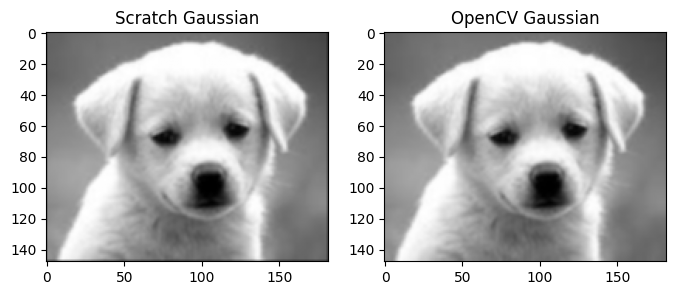

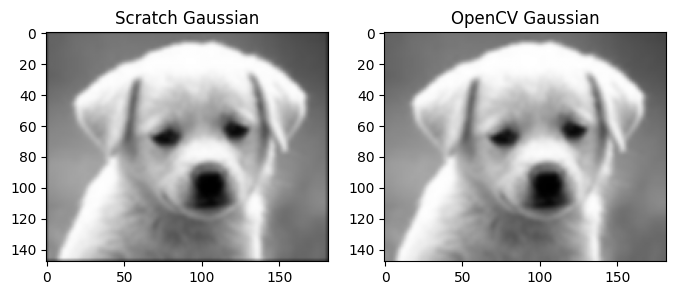

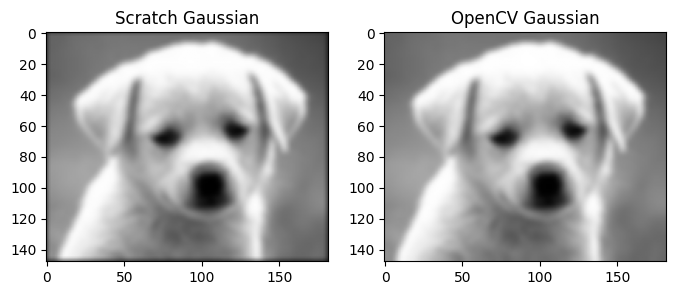

In [14]:
params = [(3,1.0),(5,1.5),(7,2.0)]

for size,sigma in params:

    kernel = gaussian_kernel(size,sigma)

    blur = convolution2D(dog,kernel)

    cv_blur = cv2.GaussianBlur(dog,(size,size),sigma)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(blur,cmap='gray')
    plt.title("Scratch Gaussian")

    plt.subplot(1,2,2)
    plt.imshow(cv_blur,cmap='gray')
    plt.title("OpenCV Gaussian")

    plt.show()

#Part (c) Separable Gaussian Filtering
#1D Gaussian

In [15]:
def gaussian1D(size,sigma):

    ax = np.arange(-(size//2), size//2 + 1)

    kernel = np.exp(-(ax**2)/(2*sigma**2))

    kernel = kernel / np.sum(kernel)

    return kernel

#Separable Filtering

In [16]:
def separable_gaussian(image,size,sigma):

    k = gaussian1D(size,sigma)

    temp = convolution2D(image,k.reshape(1,-1))

    result = convolution2D(temp,k.reshape(-1,1))

    return result

#Compare Time

In [17]:
start = time.time()

sep = separable_gaussian(dog,5,1.5)

end = time.time()

print("Separable Time:", end-start)

start = time.time()

kernel = gaussian_kernel(5,1.5)

normal = convolution2D(dog,kernel)

end = time.time()

print("Normal 2D Time:", end-start)

Separable Time: 0.029697656631469727
Normal 2D Time: 0.18237924575805664


# QUESTION 3 — Edge Detection
Part (a) Gradient Operators

In [18]:
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

prewitt_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])

roberts_x = np.array([[1,0],[0,-1]])
roberts_y = np.array([[0,1],[-1,0]])

# Gradient Function

In [19]:
def gradient(image,kx,ky):

    gx = convolution2D(image,kx)

    gy = convolution2D(image,ky)

    magnitude = np.sqrt(gx**2 + gy**2)

    direction = np.arctan2(gy,gx)

    return gx,gy,magnitude,direction

# Visualize Results

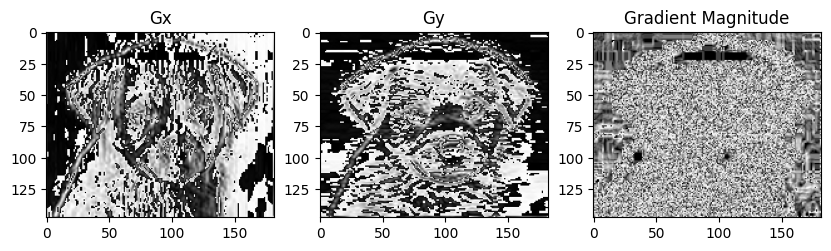

In [20]:
gx,gy,mag,dir = gradient(dog,sobel_x,sobel_y)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(gx,cmap='gray')
plt.title("Gx")

plt.subplot(1,3,2)
plt.imshow(gy,cmap='gray')
plt.title("Gy")

plt.subplot(1,3,3)
plt.imshow(mag,cmap='gray')
plt.title("Gradient Magnitude")

plt.show()

# Part (b) Canny Edge Detector
Gaussian Smoothing

In [21]:
def gaussian_smooth(img):

    kernel = gaussian_kernel(5,1)

    return convolution2D(img,kernel)

# Non-Maximum Suppression

In [22]:
def non_max_suppression(mag):

    suppressed = np.zeros_like(mag)

    for i in range(1,mag.shape[0]-1):
        for j in range(1,mag.shape[1]-1):

            if mag[i,j] >= mag[i-1,j] and mag[i,j] >= mag[i+1,j]:
                suppressed[i,j] = mag[i,j]

    return suppressed

# Hysteresis

In [23]:
def hysteresis(img,low,high):

    res = np.zeros_like(img)

    strong = 255
    weak = 75

    strong_i,strong_j = np.where(img >= high)
    weak_i,weak_j = np.where((img <= high) & (img >= low))

    res[strong_i,strong_j] = strong
    res[weak_i,weak_j] = weak

    return res

# Complete Canny

In [24]:
def canny_edge(img,low,high):

    smooth = gaussian_smooth(img)

    gx,gy,mag,dir = gradient(smooth,sobel_x,sobel_y)

    nms = non_max_suppression(mag)

    edges = hysteresis(nms,low,high)

    return edges

# Test Canny

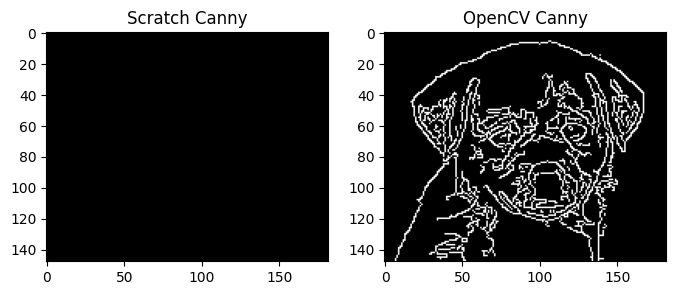

In [25]:
edges = canny_edge(dog,50,150)

cv_edges = cv2.Canny(dog,50,150)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(edges,cmap='gray')
plt.title("Scratch Canny")

plt.subplot(1,2,2)
plt.imshow(cv_edges,cmap='gray')
plt.title("OpenCV Canny")

plt.show()

# Part (c) Edge Detection Comparison

In [26]:
sobel_edges = gradient(dog,sobel_x,sobel_y)[2]

log = cv2.Laplacian(cv2.GaussianBlur(dog,(3,3),1),cv2.CV_64F)

canny = canny_edge(dog,50,150)

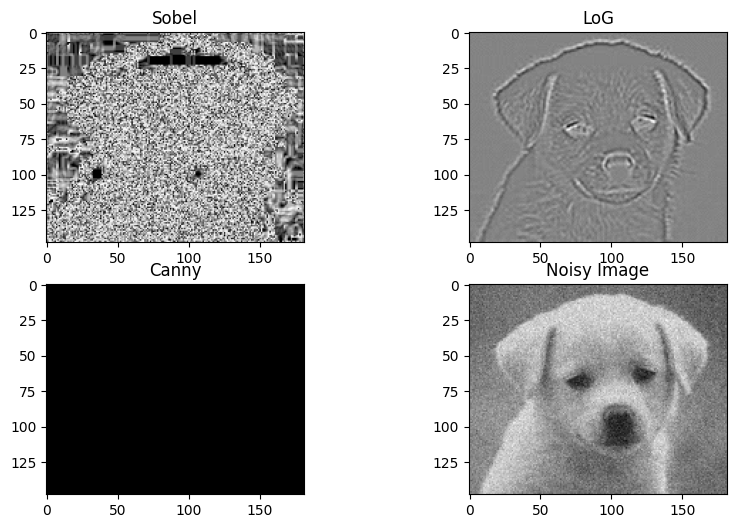

In [27]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.imshow(sobel_edges,cmap='gray')
plt.title("Sobel")

plt.subplot(2,2,2)
plt.imshow(log,cmap='gray')
plt.title("LoG")

plt.subplot(2,2,3)
plt.imshow(canny,cmap='gray')
plt.title("Canny")

noise = dog + np.random.normal(0,20,dog.shape)

plt.subplot(2,2,4)
plt.imshow(noise,cmap='gray')
plt.title("Noisy Image")

plt.show()